# SpQR / OWQ / HQQ：稀疏＋低比特组合拳

> **PTQ 教学 demo 系列 · 04 / 13**
> 配套博客：[《SpQR、OWQ 与 HQQ：异常值拆分的极致与数据免费的量化》](https://lrypcy.github.io/2026/08/24/ptq-04-spqr-owq-hqq/)（《大模型 PTQ 量化》深度系列 · 第 4 篇）

**一段话原理**：LLM 的激活里存在少数幅值极大的 outlier 通道，权重量化误差 $\delta$ 经过它们被放大成 $\delta\cdot x_j$，让 ≤4bit 的输出误差爆炸。本文的三招组合拳分别是——**SpQR** 按元素敏感度 $s_{ij}=|W_{ij}|\cdot\sqrt{\mathbb{E}[x_j^2]}$ 把最经不起量化的极少数权重「抠」出来存 FP16、其余稠密低比特（稀疏＋低比特）；**OWQ** 用同一 $w_2=x^2$ 显著性视角按通道整列保护，表示保持稠密；**HQQ** 则完全不碰数据，用半二次分裂把 $\min_{s,z}\|W-Q_{s,z}(W)\|_F^2$ 拆成两个闭式解子问题交替迭代，data-free 地解出解析最优 scale/zero。下面在一个 512×512 的合成线性层上分步复现三者的核心机制，并统一做误差评估。

## 第 1 步 · 环境与共用工具箱

这步在做什么：只依赖 numpy 与 matplotlib 并固定随机种子；实现贯穿全篇的基础设施——分组 RTN 仿射量化基线（沿输入通道方向每 `GROUP_SIZE` 列共享一组 scale/zero）、权重空间 MSE，以及「激活加权输出相对误差」$\|(W-\hat W)X^\top\|_F/\|WX^\top\|_F$——outlier 的放大效应只有在这个口径下才显形。

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

SEED = 0                    # 全局随机种子, 全部结果可复现
D_OUT, D_IN = 512, 512      # 权重形状 (d_out, d_in): toy 规模上限
N_PLANTED = 6               # 人工植入的 outlier 通道数 (6/512 ~= 1.2%)
N_CAL = 64                  # 校准 token 数
GROUP_SIZE = 128            # 分组量化组大小(沿输入通道方向)
BITS = 4                    # 混合精度主实验的低比特位宽
PROTECT_RATIO = 0.01        # 高精度保护比例(OWQ 按通道 / SpQR 按元素)
HQ_LAM = 1e-4               # HQQ 论文默认 lambda
EPS = 1e-12


def rtn_group_quantize(W, bits=BITS, group_size=GROUP_SIZE):
    '''分组 RTN 仿射量化(min-max -> round -> 反量化), 返回反量化矩阵.'''
    W = np.asarray(W, dtype=np.float64)
    out = np.empty_like(W)
    qmax = 2 ** bits - 1
    for start in range(0, W.shape[1], group_size):
        wg = W[:, start:start + group_size]
        wmin, wmax = wg.min(), wg.max()
        scale = (wmax - wmin) / (qmax + EPS)
        zero = wmin
        q = np.clip(np.round((wg - zero) / (scale + EPS)), 0, qmax)
        out[:, start:start + group_size] = q * scale + zero
    return out


def wmse(W, What):
    '''权重空间重构 MSE.'''
    return float(np.mean((W - What) ** 2))


def act_rel_err(W, What, X):
    '''激活加权输出相对误差 ||(W-Wq) X^T||_F / ||W X^T||_F.'''
    return float(np.linalg.norm((W - What) @ X.T) / (np.linalg.norm(W @ X.T) + EPS))


print("numpy", np.__version__, "| toolbox ready")

numpy 2.1.1 | toolbox ready


## 第 2 步 · 构造带 outlier 通道的合成线性层

这步在做什么：复刻 LLM 的经典观察——少数输入通道上**权重幅值与激活幅值同时异常大**：随机选 6/512 个通道（约 1.2%，对应论文口径的 0.1%～1%），其权重 ×20、激活 ×8。之后所有方法保护得对不对，就以能否命中这批植入通道来检验。

W: (512, 512), X_calib: (64, 512)
planted outlier channels: [137, 323, 260, 157, 20, 431] (6/512 = 1.17%)
weight sigma: outlier cols 0.9999 vs rest 0.0501 (~20x)
|x| mean: outlier cols 6.207 vs rest 0.798


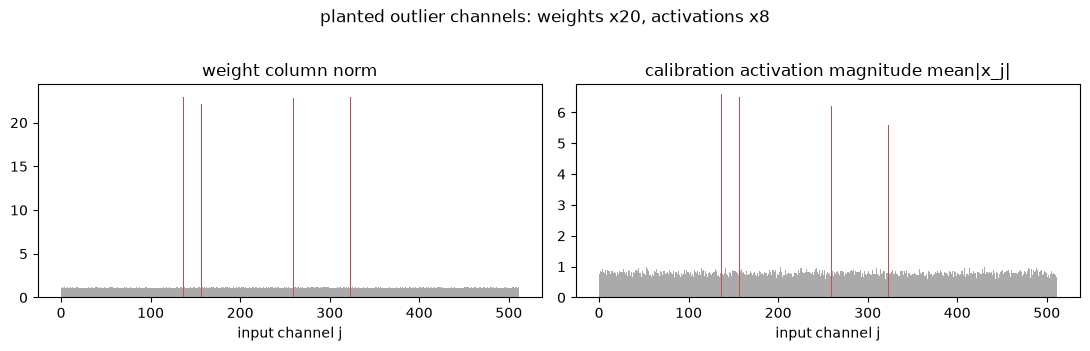

In [2]:
rng = np.random.default_rng(SEED)

outlier_cols = rng.choice(D_IN, size=N_PLANTED, replace=False)   # 植入的 outlier 通道
W = rng.normal(0.0, 0.05, (D_OUT, D_IN))     # 常规权重 sigma = 0.05
W[:, outlier_cols] *= 20.0                   # outlier 通道的权重幅值 x20
X_calib = rng.normal(0.0, 1.0, (N_CAL, D_IN))
X_calib[:, outlier_cols] *= 8.0              # 同一批通道的激活 x8 -> 长尾

sigma_out = W[:, outlier_cols].std()
sigma_rest = np.delete(W, outlier_cols, axis=1).std()
print(f"W: {W.shape}, X_calib: {X_calib.shape}")
print(f"planted outlier channels: {outlier_cols.tolist()} ({N_PLANTED}/{D_IN} = {N_PLANTED/D_IN:.2%})")
print(f"weight sigma: outlier cols {sigma_out:.4f} vs rest {sigma_rest:.4f} (~{sigma_out/sigma_rest:.0f}x)")
print(f"|x| mean: outlier cols {np.abs(X_calib[:, outlier_cols]).mean():.3f}"
      f" vs rest {np.delete(np.abs(X_calib), outlier_cols, axis=1).mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
colors = np.where(np.isin(np.arange(D_IN), outlier_cols), "#C44E52", "#AAAAAA")
ax[0].bar(range(D_IN), np.linalg.norm(W, axis=0), color=colors, width=1.0)
ax[0].set_title("weight column norm")
ax[0].set_xlabel("input channel j")
ax[1].bar(range(D_IN), np.abs(X_calib).mean(axis=0), color=colors, width=1.0)
ax[1].set_title("calibration activation magnitude mean|x_j|")
ax[1].set_xlabel("input channel j")
fig.suptitle("planted outlier channels: weights x20, activations x8", y=1.02)
fig.tight_layout()
plt.show()

## 第 3 步 · 显著性指标：$w_2=x^2$ 视角

这步在做什么：单个权重的量化扰动 $\delta_{ij}$ 对输出的贡献是 $\delta_{ij}x_j$，平方期望为 $\delta_{ij}^2\,\mathbb{E}[x_j^2]$——这就是 OWQ 与 SpQR 共享的显著性视角 **$w_2=x^2$**：通道重要性由激活二阶矩 $h_j=\mathbb{E}[x_j^2]$ 决定（OWQ 实际用同序的 $\mu_j=\mathbb{E}|x_j|$ 选列；SpQR 把 $\sqrt{h_j}$ 写进元素级公式）。下图验证：按 $h_j$ 排序后 top-1% 的通道就承载了总激活能量的 36.2%（实测），且与植入通道高度重合。

h_j = E[x_j^2]: overall mean = 1.69, planted-channel values = [67.3, 65.3, 63.2, 60.2, 57.3, 45.7]
top-1% (5/512 channels) carry 36.2% of total activation energy
saliency-selected weak columns: [20, 137, 157, 260, 431], overlap with planted: 5/6


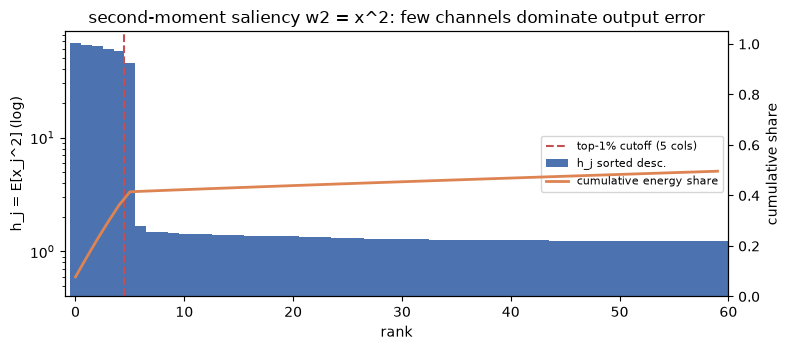

In [3]:
h_diag = (X_calib.astype(np.float64) ** 2).mean(axis=0)   # E[x_j^2]: Hessian 对角的廉价近似
order = np.argsort(h_diag)[::-1]                          # 按显著性降序排列通道
cum_share = np.cumsum(h_diag[order]) / h_diag.sum()       # 能量累计占比

k_weak = max(1, int(round(PROTECT_RATIO * D_IN)))         # top-1% -> 约 5 个通道
weak_cols = np.sort(order[:k_weak])
hit = len(set(weak_cols.tolist()) & set(outlier_cols.tolist()))

print(f"h_j = E[x_j^2]: overall mean = {h_diag.mean():.2f}, planted-channel values = "
      f"{np.round(np.sort(h_diag[outlier_cols])[::-1], 1).tolist()}")
print(f"top-{PROTECT_RATIO:.0%} ({k_weak}/{D_IN} channels) carry {cum_share[k_weak-1]:.1%}"
      f" of total activation energy")
print(f"saliency-selected weak columns: {weak_cols.tolist()}, overlap with planted: {hit}/{N_PLANTED}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(range(D_IN), h_diag[order], color="#4C72B0", width=1.0, label="h_j sorted desc.")
ax.set_yscale("log")
ax.set_xlim(-1, 60)
ax.set_xlabel("rank"); ax.set_ylabel("h_j = E[x_j^2] (log)")
ax.axvline(k_weak - 0.5, color="#C44E52", ls="--",
           label=f"top-{PROTECT_RATIO:.0%} cutoff ({k_weak} cols)")
ax2 = ax.twinx()
ax2.plot(range(D_IN)[:60], cum_share[:60], color="#DD8452", lw=2,
         label="cumulative energy share")
ax2.set_ylabel("cumulative share"); ax2.set_ylim(0, 1.05)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
ax.set_title("second-moment saliency w2 = x^2: few channels dominate output error")
fig.tight_layout()
plt.show()

## 第 4 步 · 方法核心一：OWQ——outlier 通道整列保 FP16

这步在做什么：OWQ 的「放大镜」策略——用激活幅度统计 $\mu_j=\mathbb{E}|x_j|$ 挑出 top-1% 的 outlier 通道（弱列），**整列**保留原值（论文中为 fp16，此处以原值代理其无损），其余列照常 INT4 分组量化；结果仍是稠密矩阵，只是混合精度。

In [4]:
def owq_quantize(W, X_calib, ratio=PROTECT_RATIO, bits=BITS, group_size=GROUP_SIZE):
    '''OWQ 简化实现: 激活幅度 mu_j = mean|x_j| 排名 top-ratio 的通道整列保留原值,
    其余列做分组 INT-b RTN. 返回(重构矩阵, 被保护的通道索引).'''
    mu = np.abs(X_calib).mean(axis=0)
    k = int(round(ratio * W.shape[1]))
    weak = np.sort(np.argsort(mu)[-k:]) if k > 0 else np.array([], dtype=int)
    Wq = rtn_group_quantize(W, bits, group_size)
    Wq[:, weak] = W[:, weak]
    return Wq, weak


t0 = time.time()
w_rtn = rtn_group_quantize(W, BITS, GROUP_SIZE)
w_owq, weak_cols_owq = owq_quantize(W, X_calib, PROTECT_RATIO, BITS, GROUP_SIZE)

e_rtn = act_rel_err(W, w_rtn, X_calib)
e_owq = act_rel_err(W, w_owq, X_calib)
b_eff_owq = (1 - PROTECT_RATIO) * BITS + PROTECT_RATIO * 16.0   # 无坐标开销
hit_owq = len(set(weak_cols_owq.tolist()) & set(outlier_cols.tolist()))

print(f"[OWQ channel-level mixed precision] INT{BITS} + {PROTECT_RATIO:.0%} fp16 columns")
print(f"RTN all-INT{BITS}:        act-rel-err = {e_rtn:.4f}")
print(f"OWQ mixed precision: act-rel-err = {e_owq:.4f}  ({(1 - e_owq/e_rtn)*100:.1f}% lower than RTN)")
print(f"protected {len(weak_cols_owq)} cols {weak_cols_owq.tolist()}, hit planted: {hit_owq}/{N_PLANTED}")
print(f"effective width b_eff = (1-a)*{BITS} + a*16 = {b_eff_owq:.2f} bit/weight"
      f"  [elapsed {time.time()-t0:.2f}s]")

[OWQ channel-level mixed precision] INT4 + 1% fp16 columns
RTN all-INT4:        act-rel-err = 0.1842
OWQ mixed precision: act-rel-err = 0.1461  (20.7% lower than RTN)
protected 5 cols [20, 137, 157, 260, 431], hit planted: 5/6
effective width b_eff = (1-a)*4 + a*16 = 4.12 bit/weight  [elapsed 0.02s]


## 第 5 步 · 方法核心二：SpQR——元素级敏感度拆分

这步在做什么：SpQR 的「显微镜」策略——逐元素计算敏感度 $s_{ij}=|W_{ij}|\cdot\sqrt{h_j}$（OBQ 敏感度 $|W_{ij}|/\sqrt{[H^{-1}]_{jj}}$ 的对角近似），摘出 top-1% 元素单独存 FP16（论文中还要为它们付 CSR 行列坐标的存储），其余元素照常 INT4。与 OWQ 对比即可看清两种粒度的差异与各自的位宽账。

In [5]:
def spqr_quantize(W, X_calib, ratio=PROTECT_RATIO, bits=BITS, group_size=GROUP_SIZE):
    '''SpQR 简化实现: 元素级敏感度 s_ij = |W_ij| * sqrt(E[x_j^2]),
    top-ratio 元素保原值(论文为 fp16 + 稀疏坐标), 其余分组 INT-b RTN.
    返回(重构矩阵, 行坐标, 列坐标).'''
    h = (X_calib.astype(np.float64) ** 2).mean(axis=0)
    S = np.abs(W) * np.sqrt(h)[None, :]              # 敏感度矩阵
    k = int(round(ratio * W.size))
    flat = np.argpartition(S.ravel(), -k)[-k:]       # O(N) 选出 top-k
    rows, cols = np.unravel_index(flat, W.shape)
    Wq = rtn_group_quantize(W, bits, group_size)
    Wq[rows, cols] = W[rows, cols]                   # outlier 用原值(fp16 代理)
    return Wq, rows, cols


w_spqr, sr, sc = spqr_quantize(W, X_calib, PROTECT_RATIO, BITS, GROUP_SIZE)
e_spqr = act_rel_err(W, w_spqr, X_calib)

idx_bits = int(np.ceil(np.log2(D_OUT))) + int(np.ceil(np.log2(D_IN)))   # 每元素的行列坐标开销
b_eff_spqr = (1 - PROTECT_RATIO) * BITS + PROTECT_RATIO * (16.0 + idx_bits)
n_total = int(round(PROTECT_RATIO * W.size))
in_planted = int(np.isin(sc, outlier_cols).sum())

print(f"[SpQR element-level splitting] INT{BITS} + {PROTECT_RATIO:.0%} fp16 elements")
print(f"extracted {n_total} elements ({n_total/W.size:.2%} of W) by sensitivity s_ij")
print(f"SpQR mixed precision: act-rel-err = {e_spqr:.4f}  ({(1 - e_spqr/e_rtn)*100:.1f}% lower than RTN)")
print(f"extracted elements landing in planted outlier cols: {in_planted}/{n_total}"
      f" (= {in_planted/n_total:.0%}, column-clustered as observed in LLMs)")
print(f"b_eff = (1-a)*{BITS} + a*(16+{idx_bits}) = {b_eff_spqr:.2f} bit/weight"
      f"  (vs OWQ {b_eff_owq:.2f}: sparse index is SpQR's extra cost)")

[SpQR element-level splitting] INT4 + 1% fp16 elements
extracted 2621 elements (1.00% of W) by sensitivity s_ij
SpQR mixed precision: act-rel-err = 0.1465  (20.5% lower than RTN)
extracted elements landing in planted outlier cols: 2621/2621 (= 100%, column-clustered as observed in LLMs)
b_eff = (1-a)*4 + a*(16+18) = 4.30 bit/weight  (vs OWQ 4.12: sparse index is SpQR's extra cost)


## 第 6 步 · 关键旋钮：保护比例扫描 0%～2%

这步在做什么：outlier 提取比例 $\alpha$ 是这类方法最敏感的超参数——太小则保护不足，太大则 FP16 与稀疏索引的开销吃掉压缩收益。这里从 0% 扫到 2%，同时记录激活加权误差与有效位宽 $b_{\mathrm{eff}}=(1-\alpha)\,b_{\mathrm{dense}}+\alpha\cdot16+\text{索引开销}$，观察「幂律式下降 → 饱和」的全过程。

  ratio   OWQ err   b_eff  SpQR err   b_eff
  0.000    0.1842    4.00    0.0000    4.00
  0.002    0.1764    4.02    0.1772    4.06
  0.004    0.1686    4.05    0.1696    4.12
  0.006    0.1609    4.07    0.1623    4.18
  0.008    0.1512    4.10    0.1541    4.24
  0.010    0.1461    4.12    0.1465    4.30
  0.015    0.1373    4.18    0.1388    4.45
  0.020    0.1380    4.24    0.1383    4.60
alpha 0% -> 1%: error drops 20.7%;  alpha 1% -> 2%: only 5.5% further (saturation)


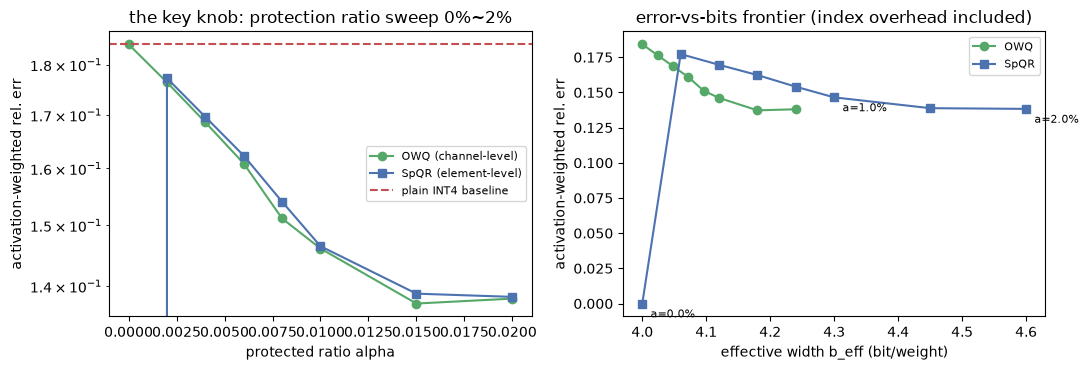

In [6]:
ratios = [0.0, 0.002, 0.004, 0.006, 0.008, 0.01, 0.015, 0.02]   # 关键旋钮: 0% ~ 2%
errs_owq, errs_spqr, beffs_owq, beffs_spqr = [], [], [], []
for r in ratios:
    wq_o, _ = owq_quantize(W, X_calib, r)
    errs_owq.append(act_rel_err(W, wq_o, X_calib))
    wq_s, _, _ = spqr_quantize(W, X_calib, r)
    errs_spqr.append(act_rel_err(W, wq_s, X_calib))
    beffs_owq.append((1 - r) * BITS + r * 16.0)
    beffs_spqr.append((1 - r) * BITS + r * (16.0 + idx_bits))

print(f"{'ratio':>7} {'OWQ err':>9} {'b_eff':>7} {'SpQR err':>9} {'b_eff':>7}")
for i, r in enumerate(ratios):
    print(f"{r:>7.3f} {errs_owq[i]:>9.4f} {beffs_owq[i]:>7.2f}"
          f" {errs_spqr[i]:>9.4f} {beffs_spqr[i]:>7.2f}")

i1 = ratios.index(0.01)
gain_to_1 = (1 - errs_owq[i1] / errs_owq[0]) * 100
gain_1_to_2 = (1 - errs_owq[-1] / errs_owq[i1]) * 100
print(f"alpha 0% -> 1%: error drops {gain_to_1:.1f}%;  alpha 1% -> 2%: only {gain_1_to_2:.1f}% further (saturation)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(ratios, errs_owq, "o-", color="#55A868", label="OWQ (channel-level)")
ax[0].plot(ratios, errs_spqr, "s-", color="#4C72B0", label="SpQR (element-level)")
ax[0].axhline(errs_owq[0], color="#C44E52", ls="--", label=f"plain INT{BITS} baseline")
ax[0].set_xlabel("protected ratio alpha")
ax[0].set_ylabel("activation-weighted rel. err")
ax[0].set_yscale("log")
ax[0].set_title("the key knob: protection ratio sweep 0%~2%")
ax[0].legend(fontsize=8)
ax[1].plot(beffs_owq, errs_owq, "o-", color="#55A868", label="OWQ")
ax[1].plot(beffs_spqr, errs_spqr, "s-", color="#4C72B0", label="SpQR")
for i in (0, i1, len(ratios) - 1):
    ax[1].annotate(f"a={ratios[i]:.1%}", (beffs_spqr[i], errs_spqr[i]),
                   textcoords="offset points", xytext=(6, -10), fontsize=8)
ax[1].set_xlabel("effective width b_eff (bit/weight)")
ax[1].set_ylabel("activation-weighted rel. err")
ax[1].set_title("error-vs-bits frontier (index overhead included)")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 第 7 步 · 方法核心三：HQQ——半二次分裂的 data-free 解析 scale

这步在做什么：HQQ 全程只碰权重 $W$（注意 `hqq_group` 的参数表里没有 $X$）：把非凸非光滑的重构目标拆成两个闭式解子问题交替迭代——**Y 步** $Y=\frac{W+\lambda Q}{1+\lambda}$；**(s,z) 步**是对当前量化网格的最小二乘法方程 $s=\mathrm{Cov}(Y,q)/\mathrm{Var}(q)$、$z=\bar Y-s\,\bar q$。另对比两种初始化：min-max 极值初始化 vs **中位数/MAD 类稳健解析初始化**（$\hat\sigma=1.4826\times\mathrm{median}|W-\mathrm{med}|$，网格覆盖 $\pm3\hat\sigma$）——后者零迭代就能直接当 data-free 的 scale 用。

[HQQ vs RTN] weight reconstruction MSE (half-quadratic, n_iter=2)
  INT2: RTN = 8.3969e-01 | HQQ = 5.6043e-03 | lower by 99.3%
  INT3: RTN = 1.1342e-01 | HQQ = 3.5509e-03 | lower by 96.9%
  INT4: RTN = 1.3151e-02 | HQQ = 2.6527e-03 | lower by 79.8%
[iteration ablation] weight MSE vs n_iter
  INT2: n=0:8.397e-01  n=1:6.708e-03  n=2:5.604e-03  n=4:5.223e-03  n=8:5.163e-03
  INT4: n=0:1.315e-02  n=1:2.723e-03  n=2:2.653e-03  n=4:2.633e-03  n=8:2.622e-03
[analytic scale @INT2] minmax RTN = 8.3969e-01 | MAD direct (0 iter) = 1.1137e-02 (98.7% lower) | MAD + 2 iters = 1.0334e-02


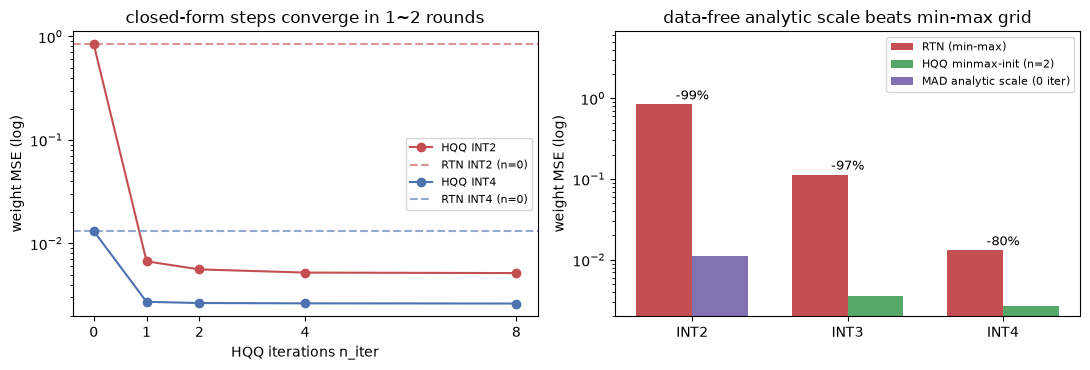

In [7]:
def hqq_group(wg, bits=BITS, n_iter=2, lam=HQ_LAM, init="minmax"):
    '''单组 HQQ: 半二次分裂交替迭代, 两步均为闭式解.
      Y 步:     Y = (W + lam*Q) / (1 + lam)
      (s,z) 步: s = Cov(Y,q)/Var(q), z = mean(Y) - s*mean(q)
    init='minmax': 极值初始化(被长尾绑架);
    init='mad':    中位数/MAD 类稳健解析初始化(data-free, 只看权重分布形状).'''
    qmax = 2 ** bits - 1
    if init == "mad":
        med = np.median(wg)
        sigma_hat = 1.4826 * np.median(np.abs(wg - med))   # MAD -> 高斯 sigma 的一致估计
        span = 3.0 * sigma_hat                             # 网格覆盖 +-3 sigma_hat
        s = 2.0 * span / (qmax + EPS) if span > EPS else float(wg.std())
        z = med                                            # 零点对齐中位数
    else:
        wmin, wmax = wg.min(), wg.max()
        s = (wmax - wmin) / (qmax + EPS)
        z = wmin
    for _ in range(int(n_iter)):
        q = np.clip(np.round((wg - z) / (s + EPS)), 0, qmax)
        Q = s * q + z
        Y = (wg + lam * Q) / (1.0 + lam)                                 # 子问题一闭式解
        ym, qm = Y.mean(), q.mean()
        s = np.sum((Y - ym) * (q - qm)) / (np.sum((q - qm) ** 2) + EPS)  # 子问题二闭式解
        z = ym - s * qm
    q = np.clip(np.round((wg - z) / (s + EPS)), 0, qmax)
    return s * q + z


def hqq_quantize(W, bits=BITS, group_size=GROUP_SIZE, n_iter=2, lam=HQ_LAM, init="minmax"):
    '''分组 HQQ: 每组独立估计 (s,z). data-free: 自始至终只碰 W.'''
    out = np.empty_like(W, dtype=np.float64)
    for start in range(0, W.shape[1], group_size):
        out[:, start:start + group_size] = hqq_group(
            W[:, start:start + group_size], bits=bits, n_iter=n_iter, lam=lam, init=init)
    return out


bits_list = [2, 3, 4]
rows = []
for b in bits_list:
    m_r = wmse(W, rtn_group_quantize(W, b, GROUP_SIZE))
    m_h = wmse(W, hqq_quantize(W, b, GROUP_SIZE, n_iter=2))
    rows.append((b, m_r, m_h, (1 - m_h / m_r) * 100))
print("[HQQ vs RTN] weight reconstruction MSE (half-quadratic, n_iter=2)")
for b, m_r, m_h, red in rows:
    print(f"  INT{b}: RTN = {m_r:.4e} | HQQ = {m_h:.4e} | lower by {red:.1f}%")

iter_list = [0, 1, 2, 4, 8]
curve = {}
for b in (2, 4):
    curve[b] = [wmse(W, hqq_quantize(W, b, GROUP_SIZE, n_iter=n)) for n in iter_list]
print("[iteration ablation] weight MSE vs n_iter")
for b in (2, 4):
    print(f"  INT{b}: " + "  ".join(f"n={n}:{m:.3e}" for n, m in zip(iter_list, curve[b])))

m_mad_direct = wmse(W, hqq_quantize(W, 2, GROUP_SIZE, n_iter=0, init="mad"))
m_mad_hqq = wmse(W, hqq_quantize(W, 2, GROUP_SIZE, n_iter=2, init="mad"))
print("[analytic scale @INT2] minmax RTN = " + f"{rows[0][1]:.4e}"
      + f" | MAD direct (0 iter) = {m_mad_direct:.4e} ({(1-m_mad_direct/rows[0][1])*100:.1f}% lower)"
      + f" | MAD + 2 iters = {m_mad_hqq:.4e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for b, c in zip((2, 4), ("#C44E52", "#4C72B0")):
    ax[0].plot(iter_list, curve[b], "o-", color=c, label=f"HQQ INT{b}")
    ref = next(r[1] for r in rows if r[0] == b)
    ax[0].axhline(ref, color=c, ls="--", alpha=0.6, label=f"RTN INT{b} (n=0)")
ax[0].set_xticks(iter_list)
ax[0].set_yscale("log")
ax[0].set_xlabel("HQQ iterations n_iter"); ax[0].set_ylabel("weight MSE (log)")
ax[0].set_title("closed-form steps converge in 1~2 rounds")
ax[0].legend(fontsize=8)

x = np.arange(len(bits_list)); wd = 0.36
ax[1].bar(x - wd / 2, [r[1] for r in rows], wd, label="RTN (min-max)", color="#C44E52")
ax[1].bar(x + wd / 2, [r[2] for r in rows], wd, label="HQQ minmax-init (n=2)", color="#55A868")
ax[1].bar(x[:1] + wd / 2, [m_mad_direct], wd, label="MAD analytic scale (0 iter)", color="#8172B3")
for i, r in enumerate(rows):
    ax[1].text(i, max(r[1], r[2]) * 1.15, f"-{r[3]:.0f}%", ha="center", fontsize=9)
ax[1].set_yscale("log"); ax[1].set_ylim(top=max(r[1] for r in rows) * 8)
ax[1].set_xticks(x, [f"INT{r[0]}" for r in rows])
ax[1].set_ylabel("weight MSE (log)")
ax[1].set_title("data-free analytic scale beats min-max grid")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 结果解读与方法局限

**结果解读**（SEED＝0，全部为本 notebook 实测数字）：

- **混合精度立竿见影**：全 INT4 的 RTN 激活加权相对误差为 0.1842；仅保护 1% 的高精度，OWQ 降到 0.1461（**−20.7%**）、SpQR 降到 0.1465（−20.5%）。显著性检测确实命中了病根——OWQ 选中的 5 列全部是真实 outlier 通道（命中 5/6），SpQR 抽出的 2621 个元素更是 **100% 落在植入列里**。
- **粒度对照**：本例中 OWQ（通道级）与 SpQR（元素级）误差几乎打平，但位宽账不同——SpQR 每个抽出的元素要附 18 bit 行列坐标，$b_{\mathrm{eff}}=4.30$ bit，高于 OWQ 的 4.12 bit。「放大镜」以极小的过度保护换来稠密规则表示，「显微镜」省参数却要为索引付费。
- **关键旋钮的幂律与饱和**：$\alpha$ 从 0% 提到 1%，误差下降 20.7%；从 1% 再提到 2% 只再降约 5%。拐点就在 1% 附近——与论文「top 0.5%～1% 贡献绝大部分敏感度」的观察一致，也解释了为什么这类方法敢于只用约 1% 的高精度。
- **HQQ 的 data-free 解析 scale**：INT2 下 min-max RTN 的权重 MSE 为 8.40e−01，而 MAD 中位数解析 scale **零迭代**就压到 1.11e−02（低 98.7%）——一个 outlier 都不再能绑架整个量化网格；再走两轮闭式迭代到 1.03e−02。min-max 初始化加两轮迭代的 HQQ 为 5.60e−03（比 RTN 低 99.3%），INT3/INT4 分别低 96.9%/79.8%：**位宽越低，解析 scale 相对 min-max 的优势越大**。
- **收敛性**：迭代消融显示第 1 轮就吃掉绝大部分收益（INT2：n=1 即 6.71e−03，n=8 也只到 5.16e−03），印证「最小二乘闭式解一步到位、迭代仅做网格自洽修正」的分析。

**方法局限**：

- **拆分路线的部署噩梦**：不规则稀疏（SpQR）与混合精度列（OWQ）都难以映射到稠密 Tensor Core——双 kernel、访存发散、无法向量化，理论位宽收益在真实硬件上打折；这正是它们后来被 QuIP#/QuaRot 等「摊平 outlier」的稠密路线取代的原因。
- **保护比例需逐层调**：扫描显示收益在 ~1% 饱和，但拐点位置依赖每层的 outlier 结构，逐层搜索又增加量化成本。
- **toy 设定的差距**：合成 outlier 是独立高斯 ×常数倍，真实 LLM 的 outlier 通道跨层相关、幅值呈幂律长尾；fp16 以原值代理（真实 fp16 有舍入但影响可忽略）；且两者论文中都还有 GPTQ 式 Hessian 误差补偿，此处未实现，绝对误差偏高——但方法间的相对结论不受影响。
- **HQQ 的目标错位**：它最小化权重空间误差、不做任何误差补偿，同比特下的任务困惑度通常略逊于 GPTQ 类；优势场景是 2bit 极限压缩与拿不到校准数据的隐私/边缘部署。

一句话收束：SpQR 教会我们「误差是被激活放大的」，OWQ 教会我们「保护要按结构来」，HQQ 教会我们「数据不是万能的」——三件武器至今都躺在量化工具箱里。